# Part 3: LightGBM 模型训练及评估

请先运行 `01_dependencies_and_data.ipynb`。

In [17]:
"""Part 3: LightGBM. Run 01_dependencies_and_data.ipynb first."""
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import os
import dill
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = "C:\\ML4GM"
outputs_dir = os.path.join(root_dir, "models")

def load_pkl(filepath):
    with open(filepath, "rb") as fr:
        return dill.load(fr)

def save_pkl(filepath, data):
    with open(filepath, "wb") as fw:
        dill.dump(data, fw)
    print(f"[{filepath}] data saved.")

_data = load_pkl(os.path.join(outputs_dir, "preprocessed_data.pkl"))
# 强制转为普通 ndarray（防止 memmap 在 Windows loky 子进程中无法访问）
X_all       = np.asarray(_data["X_all"],     dtype=np.float64)
y_all       = np.asarray(_data["y_all"],     dtype=np.float64)
rgiid_all   = np.asarray(_data["rgiid_all"])
year_all    = np.asarray(_data["year_all"])
feature_columns = _data["feature_columns"]

print(f"Loaded: X_all={X_all.shape}, y_all={y_all.shape}, years={sorted(np.unique(year_all))}")
print(f"X_all type: {type(X_all)}, dtype: {X_all.dtype}")

Loaded: X_all=(162020, 46), y_all=(162020,), years=[np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
X_all type: <class 'numpy.ndarray'>, dtype: float64


In [ ]:
# # ============================================================
# # 【快速启动】跳过调参，直接从验证部分运行时执行此 Cell
# # 前提：已至少完整运行过一次调参 Cell，lgbm_best_params.pkl 存在
# # ============================================================
# _bp_path = os.path.join(outputs_dir, "lgbm_best_params.pkl")
# best_params = load_pkl(_bp_path)
# print(f"[快速启动] best_params 已从 {_bp_path} 加载：")
# print(best_params)

In [ ]:
import warnings
import numpy as np
import joblib
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score

# ---- 参数网格 ----
param_grid_lgbm = {
    "n_estimators":  [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves":    [31, 63, 127],
    "max_depth":     [-1, 15, 30],
    "subsample":     [0.7, 0.9],
}
params_list = list(ParameterGrid(param_grid_lgbm))
N_JOBS      = 60

kf        = KFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(kf.split(X_all, y_all))

print(f"搜索空间: {len(params_list)} 组合 × 5 折 = {len(params_list)*5} fits")

def eval_candidate(params):
    """对单组超参数做 5-fold CV，返回 (平均 neg-RMSE, 平均 R2)。"""
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
    from sklearn.metrics import mean_squared_error, r2_score
    rmse_scores, r2_scores = [], []
    for tr_idx, te_idx in cv_splits:
        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_all[tr_idx])
        X_te = sc.transform(X_all[te_idx])
        m    = lgb.LGBMRegressor(
            **params,
            random_state=42, n_jobs=1, verbose=-1,
            colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        )
        m.fit(X_tr, y_all[tr_idx])
        y_pred = m.predict(X_te)
        rmse_scores.append(-np.sqrt(mean_squared_error(y_all[te_idx], y_pred)))
        r2_scores.append(r2_score(y_all[te_idx], y_pred))
    return float(np.mean(rmse_scores)), float(np.mean(r2_scores))

_jbl_ver   = tuple(int(x) for x in joblib.__version__.split(".")[:2])
_return_as = "generator" if _jbl_ver >= (1, 2) else "list"

results_iter = joblib.Parallel(
    n_jobs     = N_JOBS,
    return_as  = _return_as,
    prefer     = "processes",
    batch_size = 1,
)(joblib.delayed(eval_candidate)(p) for p in params_list)

scores = []
for i, (neg_rmse, r2) in enumerate(results_iter, 1):
    scores.append(neg_rmse)
    print(f"[{i:3d}/{len(params_list)}] RMSE={-neg_rmse:.4f}  R2={r2:.4f}  params={params_list[i-1]}")

best_idx = int(np.argmax(scores))
best_params = {
    **params_list[best_idx],
    "random_state": 42, "n_jobs": -1, "verbose": -1,
    "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1,
}
print(f"\n[LGBM 调参] 最优参数: {best_params}")
print(f"[LGBM 调参] CV RMSE:  {-scores[best_idx]:.4f}")

# 保存 best_params 供跳过调参时直接加载
save_pkl(os.path.join(outputs_dir, "lgbm_best_params.pkl"), best_params)
print(f"[LGBM 调参] best_params 已保存至 {os.path.join(outputs_dir, 'lgbm_best_params.pkl')}")


### LightGBM 模型训练及评估

[/openbayes/input/input0/ML4GM/models/lgbm_model.pkl] data saved.
LightGBM model trained on full dataset and saved.


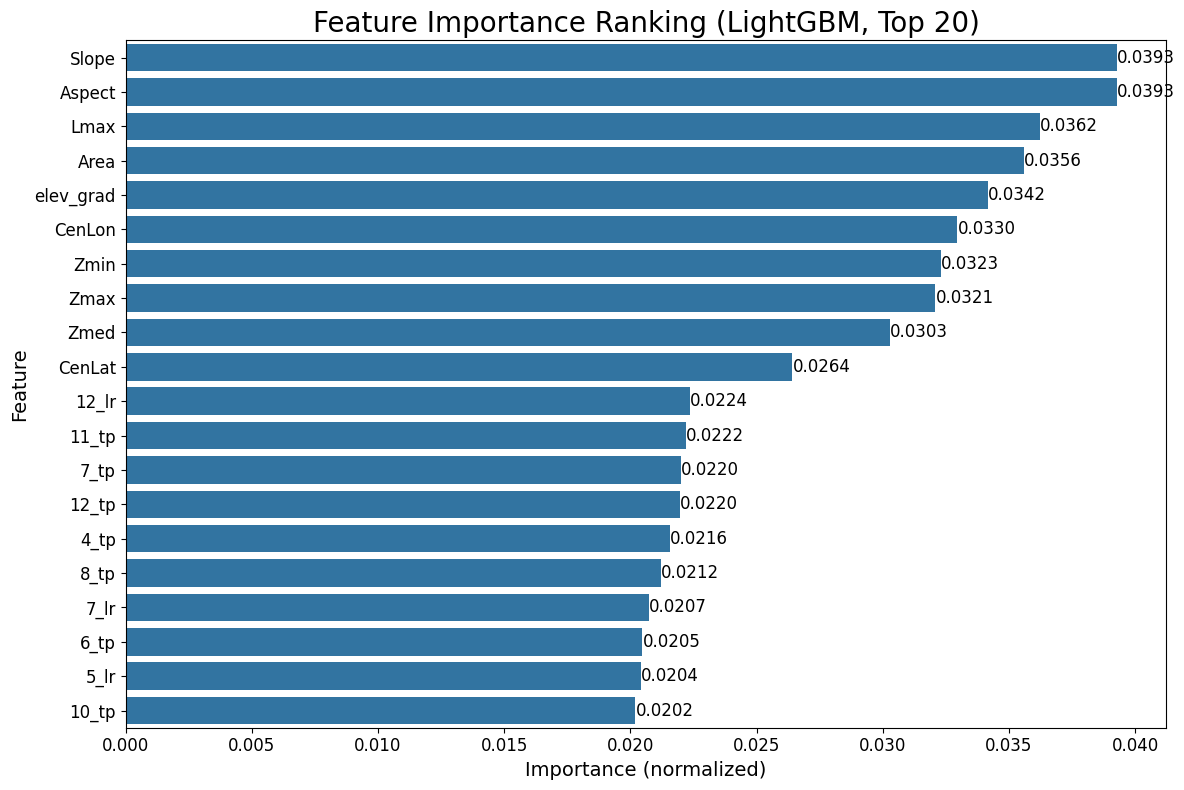

Feature importances saved.


In [3]:
# 使用调参结果在全量数据上训练 LightGBM（用于特征重要性分析）
sc_full = StandardScaler()
X_all_std = sc_full.fit_transform(X_all)

lgbm_model = lgb.LGBMRegressor(**best_params)
lgbm_model.fit(X_all_std, y_all)
save_pkl(os.path.join(outputs_dir, "lgbm_model.pkl"), lgbm_model)
print("LightGBM model trained on full dataset and saved.")

# Feature importance plot (top 20, normalized)
importances_raw  = np.array(lgbm_model.feature_importances_, dtype=float)
importances_norm = importances_raw / importances_raw.sum()
feat_imp = sorted(zip(feature_columns, importances_norm.tolist()), key=lambda x: x[1], reverse=True)
top_cols, top_imps = zip(*feat_imp[:20])

fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
sns.barplot(x=list(top_imps), y=list(top_cols), ax=ax)
for i, v in enumerate(top_imps):
    ax.text(v, i, f"{v:.4f}", ha="left", va="center", fontsize=12)
ax.set_title("Feature Importance Ranking (LightGBM, Top 20)", fontsize=20)
ax.set_xlabel("Importance (normalized)", fontsize=14)
ax.set_ylabel("Feature", fontsize=14)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()
plt.close()

pd.DataFrame({"Feature": list(top_cols), "Importance": list(top_imps)}).to_csv(
    os.path.join(outputs_dir, "feature_importances_lgbm.csv"), index=False
)
print("Feature importances saved.")

### LOYO 留一年交叉验证（Leave-One-Year-Out）

每折留出 1 个年份作为测试集，其余所有年份（所有冰川）作为训练集，共 20 折。  
参考：Bolibar et al. (2020), *The Cryosphere*, 14, 565–584.

[LOYO-LGBM] Fold  1/20 | Year 2000 | n_test=8101 | R2=0.2837 | RMSE=0.4117 | MAE=0.3064
[LOYO-LGBM] Fold  2/20 | Year 2001 | n_test=8101 | R2=0.4601 | RMSE=0.3584 | MAE=0.2657
[LOYO-LGBM] Fold  3/20 | Year 2002 | n_test=8101 | R2=0.4436 | RMSE=0.3509 | MAE=0.2653
[LOYO-LGBM] Fold  4/20 | Year 2003 | n_test=8101 | R2=0.4195 | RMSE=0.3408 | MAE=0.2539
[LOYO-LGBM] Fold  5/20 | Year 2004 | n_test=8101 | R2=0.5724 | RMSE=0.2820 | MAE=0.2140
[LOYO-LGBM] Fold  6/20 | Year 2005 | n_test=8101 | R2=0.6166 | RMSE=0.2623 | MAE=0.1988
[LOYO-LGBM] Fold  7/20 | Year 2006 | n_test=8101 | R2=0.6026 | RMSE=0.2608 | MAE=0.1949
[LOYO-LGBM] Fold  8/20 | Year 2007 | n_test=8101 | R2=0.6327 | RMSE=0.2473 | MAE=0.1840
[LOYO-LGBM] Fold  9/20 | Year 2008 | n_test=8101 | R2=0.6959 | RMSE=0.2194 | MAE=0.1667
[LOYO-LGBM] Fold 10/20 | Year 2009 | n_test=8101 | R2=0.7449 | RMSE=0.1979 | MAE=0.1475
[LOYO-LGBM] Fold 11/20 | Year 2010 | n_test=8101 | R2=0.7429 | RMSE=0.1963 | MAE=0.1470
[LOYO-LGBM] Fold 12/20 | Year 20

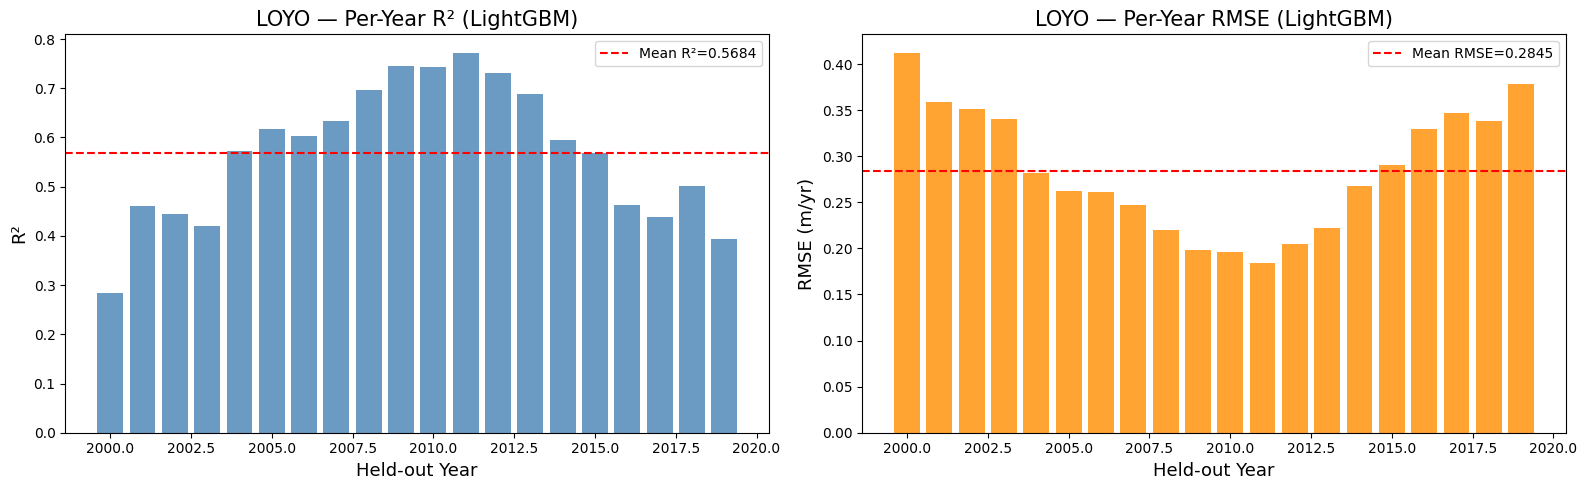

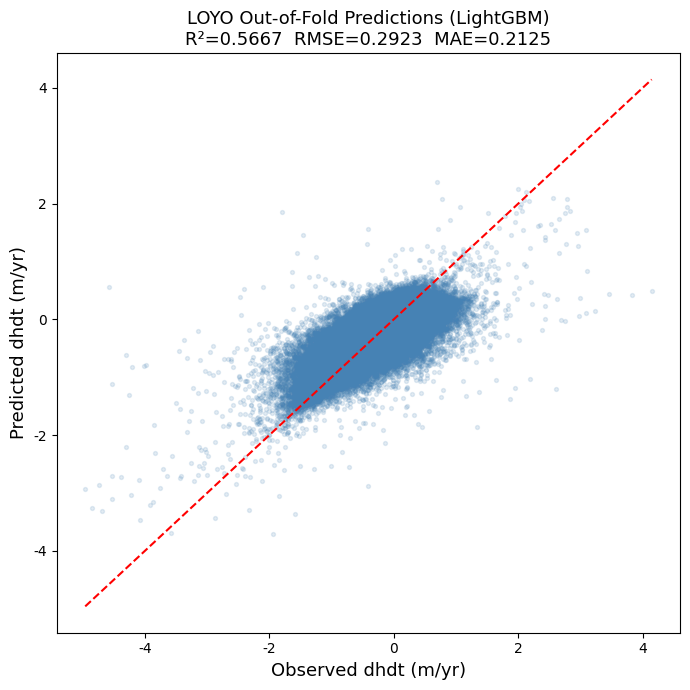

[LOYO-LGBM OOF] R²=0.5667  RMSE=0.2923  MAE=0.2125  n=162020


In [4]:
import lightgbm as lgb

# 使用调参最优超参数进行 LOYO CV
loyo_params = best_params

unique_years = sorted(np.unique(year_all))
loyo_rows = []
all_y_true, all_y_pred = [], []   # OOF 收集

for fold_i, fold_year in enumerate(unique_years, 1):
    tr_mask = year_all != fold_year
    te_mask = year_all == fold_year

    X_tr, y_tr = X_all[tr_mask], y_all[tr_mask]
    X_te, y_te = X_all[te_mask], y_all[te_mask]

    sc = StandardScaler()
    X_tr_std = sc.fit_transform(X_tr)
    X_te_std = sc.transform(X_te)

    m = lgb.LGBMRegressor(**loyo_params)
    m.fit(X_tr_std, y_tr)
    y_pred = m.predict(X_te_std)

    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(y_pred.tolist())

    r2   = float(r2_score(y_te, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae  = float(mean_absolute_error(y_te, y_pred))

    loyo_rows.append({
        "year": fold_year, "n_train": int(tr_mask.sum()),
        "n_test": int(te_mask.sum()), "R2": r2, "RMSE": rmse, "MAE": mae,
    })
    print(f"[LOYO-LGBM] Fold {fold_i:2d}/20 | Year {fold_year} | "
          f"n_test={te_mask.sum()} | R2={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")

loyo_df = pd.DataFrame(loyo_rows)
loyo_path = os.path.join(outputs_dir, "lgbm_loyo_results.csv")
loyo_df.to_csv(loyo_path, index=False)

print(f"\n[LOYO-LGBM] ===== Summary ({len(unique_years)} folds) =====")
print(f"  R²   mean={loyo_df['R2'].mean():.4f}  std={loyo_df['R2'].std():.4f}  "
      f"min={loyo_df['R2'].min():.4f}  max={loyo_df['R2'].max():.4f}")
print(f"  RMSE mean={loyo_df['RMSE'].mean():.4f}  std={loyo_df['RMSE'].std():.4f}")
print(f"  MAE  mean={loyo_df['MAE'].mean():.4f}  std={loyo_df['MAE'].std():.4f}")
print(f"  Saved to: {loyo_path}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
axes[0].bar(loyo_df["year"], loyo_df["R2"], color="steelblue", alpha=0.8)
axes[0].axhline(loyo_df["R2"].mean(), color="r", linestyle="--",
                label=f"Mean R²={loyo_df['R2'].mean():.4f}")
axes[0].set_xlabel("Held-out Year", fontsize=13)
axes[0].set_ylabel("R²", fontsize=13)
axes[0].set_title("LOYO — Per-Year R² (LightGBM)", fontsize=15)
axes[0].legend()

axes[1].bar(loyo_df["year"], loyo_df["RMSE"], color="darkorange", alpha=0.8)
axes[1].axhline(loyo_df["RMSE"].mean(), color="r", linestyle="--",
                label=f"Mean RMSE={loyo_df['RMSE'].mean():.4f}")
axes[1].set_xlabel("Held-out Year", fontsize=13)
axes[1].set_ylabel("RMSE (m/yr)", fontsize=13)
axes[1].set_title("LOYO — Per-Year RMSE (LightGBM)", fontsize=15)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()

# ---- OOF 散点图（Bolibar et al. 2020 Figure 9 风格） ----
all_y_true_np = np.array(all_y_true)
all_y_pred_np = np.array(all_y_pred)
r2_oof   = float(r2_score(all_y_true_np, all_y_pred_np))
rmse_oof = float(np.sqrt(mean_squared_error(all_y_true_np, all_y_pred_np)))
mae_oof  = float(mean_absolute_error(all_y_true_np, all_y_pred_np))

fig, ax = plt.subplots(figsize=(7, 7), dpi=100)
ax.scatter(all_y_true_np, all_y_pred_np, alpha=0.15, s=8, c="steelblue")
lims = [float(all_y_true_np.min()), float(all_y_true_np.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Observed dhdt (m/yr)", fontsize=13)
ax.set_ylabel("Predicted dhdt (m/yr)", fontsize=13)
ax.set_title(f"LOYO Out-of-Fold Predictions (LightGBM)\n"
             f"R²={r2_oof:.4f}  RMSE={rmse_oof:.4f}  MAE={mae_oof:.4f}", fontsize=13)
plt.tight_layout()
plt.show()
plt.close()
print(f"[LOYO-LGBM OOF] R²={r2_oof:.4f}  RMSE={rmse_oof:.4f}  MAE={mae_oof:.4f}  n={len(all_y_true_np)}")

### 方案一：5-fold KFold CV（随机划分）

随机将样本分成 5 折，每折 80% 作为训练集，20% 作为测试集。  
同一冰川的不同年份可能同时出现在训练集和测试集中。  
评估模型在**已知冰川未见样本**上的预测能力，与重建 2020-2025 的场景（已知冰川、未见年份）最为接近。

[LGBM KFold CV] Fold 1/5 | n_train=129616 | n_test=32404 | R2=0.7433 | RMSE=0.2252 | MAE=0.1591
[LGBM KFold CV] Fold 2/5 | n_train=129616 | n_test=32404 | R2=0.7512 | RMSE=0.2216 | MAE=0.1584
[LGBM KFold CV] Fold 3/5 | n_train=129616 | n_test=32404 | R2=0.7478 | RMSE=0.2242 | MAE=0.1579
[LGBM KFold CV] Fold 4/5 | n_train=129616 | n_test=32404 | R2=0.7434 | RMSE=0.2250 | MAE=0.1601
[LGBM KFold CV] Fold 5/5 | n_train=129616 | n_test=32404 | R2=0.7481 | RMSE=0.2213 | MAE=0.1573

[LGBM KFold CV] ===== Summary =====
  R²   mean=0.7468  std=0.0034
  RMSE mean=0.2234  std=0.0019
  MAE  mean=0.1585  std=0.0011
  Saved → C:\ML4GM\models\lgbm_kfold_cv_results.csv


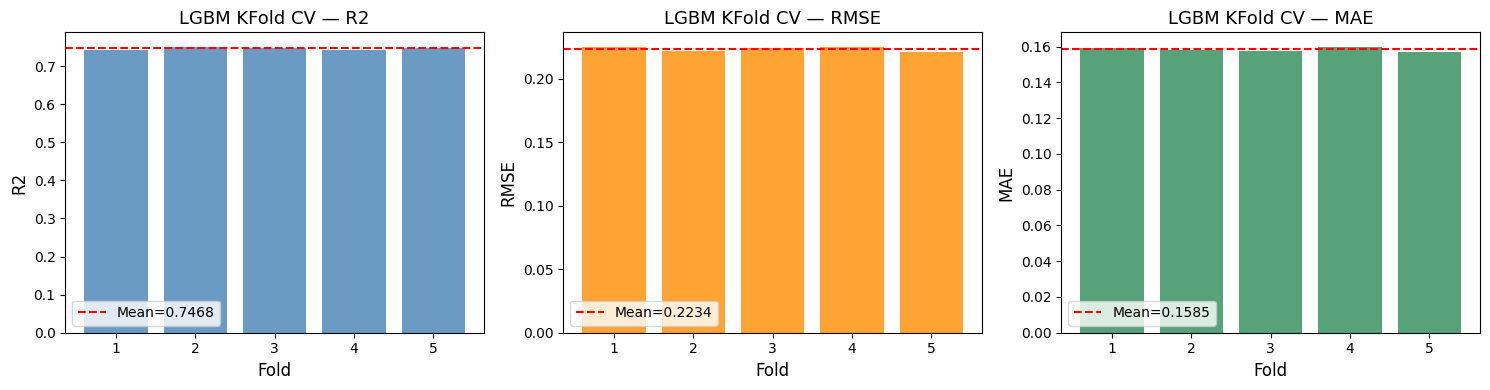

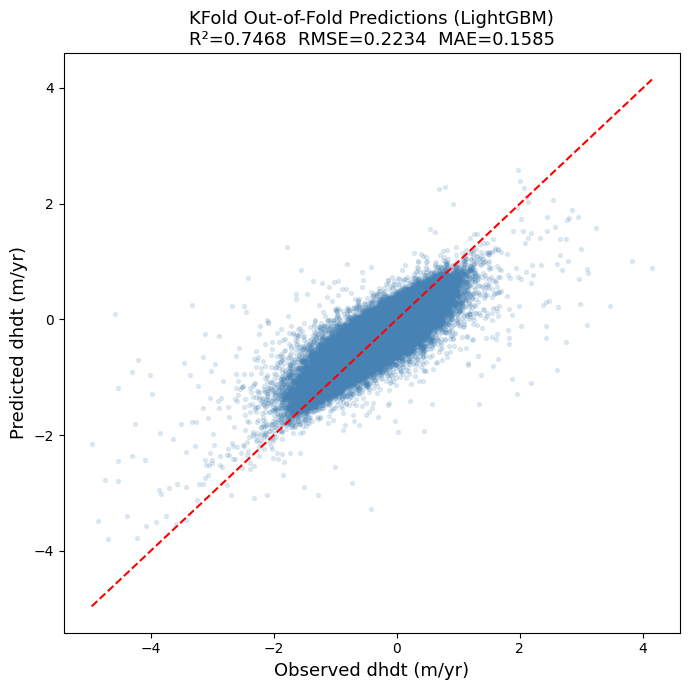

[LGBM KFold OOF] R²=0.7468  RMSE=0.2234  MAE=0.1585  n=162020


In [18]:
import lightgbm as lgb
from sklearn.model_selection import KFold

kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_rows = []
all_y_true_kf, all_y_pred_kf = [], []

for fold_i, (tr_idx, te_idx) in enumerate(kf_cv.split(X_all), 1):

    X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
    X_te, y_te = X_all[te_idx], y_all[te_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    m = lgb.LGBMRegressor(**best_params)
    m.fit(X_tr_s, y_tr)
    y_pred = m.predict(X_te_s)

    all_y_true_kf.extend(y_te.tolist())
    all_y_pred_kf.extend(y_pred.tolist())

    r2   = float(r2_score(y_te, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae  = float(mean_absolute_error(y_te, y_pred))

    kfold_rows.append({
        "fold": fold_i, "n_train": len(tr_idx), "n_test": len(te_idx),
        "R2": r2, "RMSE": rmse, "MAE": mae,
    })
    print(f"[LGBM KFold CV] Fold {fold_i}/5 | n_train={len(tr_idx)} | "
          f"n_test={len(te_idx)} | R2={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")

kfold_df = pd.DataFrame(kfold_rows)
kf_path = os.path.join(outputs_dir, "lgbm_kfold_cv_results.csv")
kfold_df.to_csv(kf_path, index=False)

print(f"\n[LGBM KFold CV] ===== Summary =====")
print(f"  R²   mean={kfold_df['R2'].mean():.4f}  std={kfold_df['R2'].std():.4f}")
print(f"  RMSE mean={kfold_df['RMSE'].mean():.4f}  std={kfold_df['RMSE'].std():.4f}")
print(f"  MAE  mean={kfold_df['MAE'].mean():.4f}  std={kfold_df['MAE'].std():.4f}")
print(f"  Saved → {kf_path}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
for ax, metric, color in zip(axes, ["R2", "RMSE", "MAE"],
                              ["steelblue", "darkorange", "seagreen"]):
    vals = kfold_df[metric]
    ax.bar(kfold_df["fold"], vals, color=color, alpha=0.8)
    ax.axhline(vals.mean(), color="r", linestyle="--",
               label=f"Mean={vals.mean():.4f}")
    ax.set_xlabel("Fold", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"LGBM KFold CV — {metric}", fontsize=13)
    ax.legend()
plt.tight_layout()
plt.show()
plt.close()

# ---- OOF 散点图 ----
all_y_true_kf_np = np.array(all_y_true_kf)
all_y_pred_kf_np = np.array(all_y_pred_kf)
r2_oof_kf   = float(r2_score(all_y_true_kf_np, all_y_pred_kf_np))
rmse_oof_kf = float(np.sqrt(mean_squared_error(all_y_true_kf_np, all_y_pred_kf_np)))
mae_oof_kf  = float(mean_absolute_error(all_y_true_kf_np, all_y_pred_kf_np))

fig, ax = plt.subplots(figsize=(7, 7), dpi=100)
ax.scatter(all_y_true_kf_np, all_y_pred_kf_np, alpha=0.15, s=8, c="steelblue")
lims = [float(all_y_true_kf_np.min()), float(all_y_true_kf_np.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Observed dhdt (m/yr)", fontsize=13)
ax.set_ylabel("Predicted dhdt (m/yr)", fontsize=13)
ax.set_title(f"KFold Out-of-Fold Predictions (LightGBM)\n"
             f"R²={r2_oof_kf:.4f}  RMSE={rmse_oof_kf:.4f}  MAE={mae_oof_kf:.4f}", fontsize=13)
plt.tight_layout()
plt.show()
plt.close()
print(f"[LGBM KFold OOF] R²={r2_oof_kf:.4f}  RMSE={rmse_oof_kf:.4f}  MAE={mae_oof_kf:.4f}  n={len(all_y_true_kf_np)}")

### 方案二：5×5 Block CV（对角线）

冰川按字典序分 5 组，年份按时间顺序分 5 组，对角线块（冰川组 i ∩ 年份组 i）轮流作为测试集。  
训练集排除测试块所在的**整行**（同冰川组所有年份）和**整列**（同年份组所有冰川），约占 64%。  
**同时消除空间泄露和时间泄露**，评估模型对未见过的冰川×时期组合的时空双重泛化能力。

In [ ]:
def make_glacier_fold(rgiid_arr, n_folds=5):
    glacier_sorted = np.sort(np.unique(rgiid_arr))
    n_glaciers = len(glacier_sorted)
    gid_to_fold = {gid: int(i * n_folds // n_glaciers)
                   for i, gid in enumerate(glacier_sorted)}
    return np.array([gid_to_fold[g] for g in rgiid_arr], dtype=int)

def make_year_fold(year_arr, n_folds=5):
    year_sorted = np.sort(np.unique(year_arr))
    n_years = len(year_sorted)
    yr_to_fold = {yr: int(i * n_folds // n_years)
                  for i, yr in enumerate(year_sorted)}
    return np.array([yr_to_fold[y] for y in year_arr], dtype=int)


[LGBM Block CV] Fold 0/4 | n_train=103680 | n_test=6484 | glaciers=1621 | R2=-0.0274 | RMSE=0.4520 | MAE=0.3205
[LGBM Block CV] Fold 1/4 | n_train=103696 | n_test=6480 | glaciers=1620 | R2=0.2903 | RMSE=0.3556 | MAE=0.2794
[LGBM Block CV] Fold 2/4 | n_train=103696 | n_test=6480 | glaciers=1620 | R2=0.3784 | RMSE=0.2643 | MAE=0.2029
[LGBM Block CV] Fold 3/4 | n_train=103696 | n_test=6480 | glaciers=1620 | R2=0.1879 | RMSE=0.2741 | MAE=0.2075
[LGBM Block CV] Fold 4/4 | n_train=103696 | n_test=6480 | glaciers=1620 | R2=0.1568 | RMSE=0.5152 | MAE=0.3683

[LGBM Block CV] ===== Summary =====
  R²   mean=0.1972  std=0.1530
  RMSE mean=0.3722  std=0.1100
  MAE  mean=0.2757  std=0.0717
  Saved → /openbayes/input/input0/ML4GM/models/lgbm_block_cv_results.csv


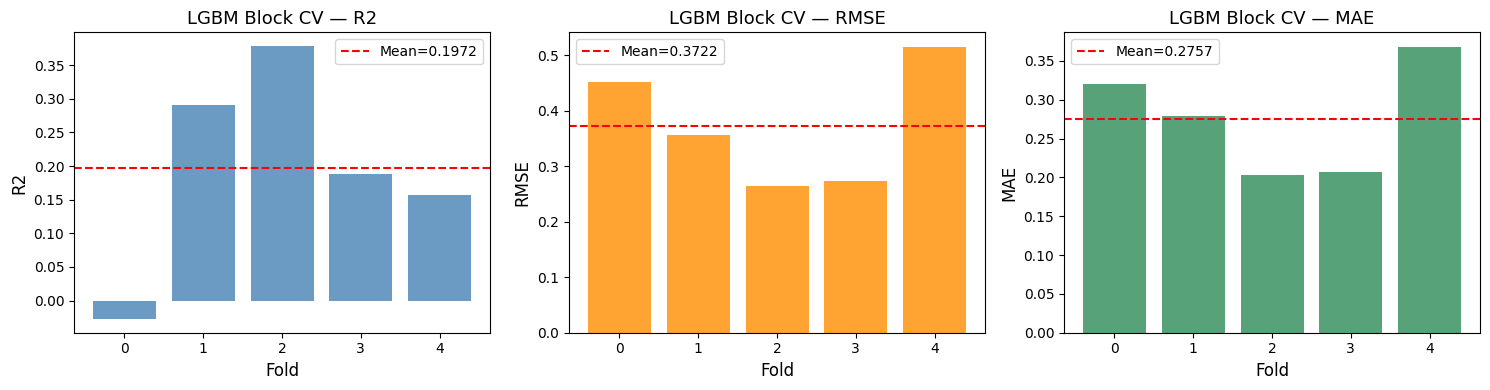

In [6]:
import lightgbm as lgb

# ── 5×5 Block CV（对角线） ────────────────────────────────────────────
glacier_fold = make_glacier_fold(rgiid_all, n_folds=5)
year_fold    = make_year_fold(year_all,    n_folds=5)

block_rows = []

for f in range(5):
    test_mask  = (glacier_fold == f) & (year_fold == f)
    train_mask = ~((glacier_fold == f) | (year_fold == f))

    assert not np.any(glacier_fold[train_mask] == f), \
        f"Block fold {f}: glacier leakage in train!"
    assert not np.any(year_fold[train_mask] == f), \
        f"Block fold {f}: year leakage in train!"

    if test_mask.sum() == 0:
        print(f"[LGBM Block CV] Fold {f}: empty test set, skipping.")
        continue

    X_tr, y_tr = X_all[train_mask], y_all[train_mask]
    X_te, y_te = X_all[test_mask],  y_all[test_mask]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    m = lgb.LGBMRegressor(**best_params)
    m.fit(X_tr_s, y_tr)
    y_pred = m.predict(X_te_s)

    r2   = float(r2_score(y_te, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae  = float(mean_absolute_error(y_te, y_pred))
    n_test_glaciers = len(np.unique(rgiid_all[test_mask]))

    block_rows.append({
        "fold": f, "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()),
        "n_test_glaciers": n_test_glaciers, "R2": r2, "RMSE": rmse, "MAE": mae,
    })
    print(f"[LGBM Block CV] Fold {f}/4 | n_train={train_mask.sum()} | "
          f"n_test={test_mask.sum()} | glaciers={n_test_glaciers} | "
          f"R2={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")

block_df = pd.DataFrame(block_rows)
blk_path = os.path.join(outputs_dir, "lgbm_block_cv_results.csv")
block_df.to_csv(blk_path, index=False)

print(f"\n[LGBM Block CV] ===== Summary =====")
print(f"  R²   mean={block_df['R2'].mean():.4f}  std={block_df['R2'].std():.4f}")
print(f"  RMSE mean={block_df['RMSE'].mean():.4f}  std={block_df['RMSE'].std():.4f}")
print(f"  MAE  mean={block_df['MAE'].mean():.4f}  std={block_df['MAE'].std():.4f}")
print(f"  Saved → {blk_path}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
for ax, metric, color in zip(axes, ["R2", "RMSE", "MAE"],
                              ["steelblue", "darkorange", "seagreen"]):
    vals = block_df[metric]
    ax.bar(block_df["fold"], vals, color=color, alpha=0.8)
    ax.axhline(vals.mean(), color="r", linestyle="--",
               label=f"Mean={vals.mean():.4f}")
    ax.set_xlabel("Fold", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"LGBM Block CV — {metric}", fontsize=13)
    ax.legend()
plt.tight_layout()
plt.show()
plt.close()